In [37]:
%load_ext autoreload
%autoreload 2

import re
import os
import sys
import random
import math
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from tqdm import tqdm_notebook
from glob import glob

sys.path.append("../src")

from word_order.process_treebank import create_word_order_df, read_df


from multiblimp.languages import get_ud_langs

from word_order.create_pairs import create_pairs
from word_order.create_tree_pairs import create_pairs_tree
from word_order.prediction_target import *
from word_order.process_treebank import load_treebank
from word_order.decision_tree import fit_dt
from word_order.entropy import order_entropy
from word_order.viz_tree import tree2html
from word_order.utils import MAX_TREEBANK_LEN

import numpy as np

import pandas as pd


def get_impurity(n, min_n=300, max_n=4000, max_val=0.1, min_val=0.01):
    if n <= min_n:
        return max_val
    if n >= max_n:
        return min_val

    t = (math.log(n) - math.log(min_n)) / (math.log(max_n) - math.log(min_n))

    return max_val - t * (max_val - min_val)


random.seed(42)
resource_dir = "/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/resources"

target = core_arg_target

core_arg_omit = [
    'nsubj_sibling-deprel-L_obj',
    'nsubj_sibling-deprel-R_obj',
    'obj_sibling-deprel-L_nsubj',
    'obj_sibling-deprel-R_nsubj',
]

deprel_dir = "_".join(target.child_deprels)
dt_df_dir = f"/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/dt_df/{deprel_dir}"
pair_dir = f"/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/pairs/{deprel_dir}"
word_order_dir = f"/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/treebank_features/{deprel_dir}"

langs = [path.split('/')[-1].split('.')[0] for path in glob(word_order_dir+"/*.csv")]

predictor_var = "deprel_order"

langs = ["English"]
lang2data = {}


for lang in tqdm_notebook(sorted(langs), total=len(langs)):
    # lang = " ".join(fn.split("_")[:-2]) or fn
    html_file = f"../word_order/decision_trees/html/{deprel_dir}/{lang}.html"

    # if os.path.exists(os.path.join(pair_dir, f"{lang}.csv")):
    #     print('skipping', lang)
    #     continue
    # if lang in lang2data:
    #     continue
    
    print(lang)
    raw_df = read_df(lang, word_order_dir=word_order_dir)
    
    full_df = raw_df[raw_df[predictor_var].notnull()]

    if len(full_df) == 0:
        continue

    # subset core_arg df
    # if 'nsubj_sibling-deprel_aux' in full_df.columns:
    #     full_df = full_df[~full_df['nsubj_sibling-deprel_aux']]
    # if 'nsubj_sibling-deprel_cop' in full_df.columns:
    #     full_df = full_df[~full_df['nsubj_sibling-deprel_cop']]
    # if 'head_Tense' in full_df.columns:
    #     full_df = full_df[~full_df.head_Tense.isna()]

    omit_feats = {col for col in full_df.columns if ('form' in col) or ('lemma' in col)}
    omit_feats.add('core_args')
    omit_feats = omit_feats.union(core_arg_omit)

    min_impurity_decrease = get_impurity(len(full_df))
    
    model, dt_df, predictor_df = fit_dt(
        full_df, 
        "decision_tree",
        target=target,
        verbose=1, 
        min_impurity_decrease=min_impurity_decrease,
        min_samples_leaf=10,
        save_to=os.path.join(dt_df_dir, lang),
        omit_feats=omit_feats,
    )

    if model is None:
        print("skipping", lang)
        continue

    balance_features = ["sen_len", "head_form"]
    balance_features += [f"{deprel}_form" for deprel in target.child_deprels]
    
    treebank = load_treebank(lang, resource_dir, max_treebank_len=MAX_TREEBANK_LEN)
    swap_df = create_pairs_tree(
        dt_df,
        treebank, 
        target,
        balance_features=balance_features,
        save_to=os.path.join(pair_dir, f"{lang}.csv"),
    )

    tree2html(
        model, 
        dt_df, 
        full_df, 
        predictor_var,
        html_file, 
        target=target,
        max_rows=15,
        meta={"Language": lang},
        only_show_real_orders=True,
        correlate_features=True,
    )

    lang2data[lang] = model, dt_df

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_73447/3859935285.py:72: TqdmDeprecationWarning:

This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`



  0%|          | 0/1 [00:00<?, ?it/s]

English
Train acc 0.9889737065309584
Test acc  0.9866666666666667


/home/jaap/gpu/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [2, 95, 187, 215, 255, 270, 286, 318, 350, 387, 390, 416, 429, 455] during transform. These unknown categories will be encoded as all zeros



333


/home/jaap/Documents/multiblimp/notebooks/../src/word_order/create_tree_pairs.py:224: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/home/jaap/Documents/multiblimp/notebooks/../src/word_order/viz_tree.py:123: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [2]:
from word_order.create_tree_pairs import create_pairs_tree

swap_df = create_pairs_tree(
    dt_df,
    treebank, 
    target,
    balance_features=balance_features,
    save_to=os.path.join(pair_dir, f"{lang}.csv"),
)
len(swap_df)

100


/home/jaap/Documents/multiblimp/notebooks/../src/word_order/create_tree_pairs.py:224: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



3866

In [129]:
from word_order.validate_swap import pos_seq_deprels, get_head_candidates


pos_seq = ["ADP", "DET", "NOUN"]
pos_df = pos_seq_deprels(treebank, pos_seq)

In [81]:
Counter(pos_df[(pos_df.dir == 0) & (pos_df.root_pos == "NOUN")].head_pos)#.total()

Counter({'VERB': 2578,
         'NOUN': 101,
         'ADJ': 92,
         'PROPN': 8,
         'ADV': 7,
         'ADP': 7,
         'PRON': 4,
         'NUM': 1,
         'DET': 1})

In [3]:
len(treebank)

15767

In [38]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../src")

from word_order.process_treebank import load_treebank
from word_order.validate_swap_directly import fit_joint_classifier
from word_order.utils import MAX_TREEBANK_LEN

resource_dir = "/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/resources"
full_df_dir = "/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/full_df"

lang = "English"

# treebank = load_treebank(lang, resource_dir, max_treebank_len=MAX_TREEBANK_LEN)

# combined_df = create_word_order_df(treebank=treebank, drop_singleton_columns=True, save_to=full_df_dir, lang=lang)

# head_df, child_df = split_node_dfs(combined_df)

# all_feats, _, all_deprel, all_pos = get_all_feats(treebank)

# classifiers = fit_reattachment_classifiers(
#     head_df, child_df, all_feats, all_deprel, all_pos, verbose=True, viz_dir="../word_order/validation_trees"
# )

n_samples = 20_000

joint_classifier, df = fit_joint_classifier(
    treebank,
    n_samples,
    "gradient_boosting",
    # train_df=df[df.child_pos=="NOUN"],
    verbose = True,
    viz_dir="../word_order/attachment_trees",
    max_depth=25,
    min_impurity_decrease=0.001,
    min_samples_leaf=25,
    sample_from_same_head=False,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 0.435936
[100]	valid_0's multi_logloss: 0.308952
[150]	valid_0's multi_logloss: 0.260471
[200]	valid_0's multi_logloss: 0.235227
[250]	valid_0's multi_logloss: 0.220378
[300]	valid_0's multi_logloss: 0.210567
[350]	valid_0's multi_logloss: 0.203753
[400]	valid_0's multi_logloss: 0.198573
[450]	valid_0's multi_logloss: 0.194326
[500]	valid_0's multi_logloss: 0.191191
[550]	valid_0's multi_logloss: 0.188627
[600]	valid_0's multi_logloss: 0.186086
[650]	valid_0's multi_logloss: 0.183983
[700]	valid_0's multi_logloss: 0.182202
[750]	valid_0's multi_logloss: 0.180609
[800]	valid_0's multi_logloss: 0.179182
[850]	valid_0's multi_logloss: 0.177976
[900]	valid_0's multi_logloss: 0.176711
[950]	valid_0's multi_logloss: 0.175801
[1000]	valid_0's multi_logloss: 0.174667
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.174667
Train acc 0.9749166666666667
Test acc  0.93625


In [17]:
df#[df.child_pos=="ADJ"]

,tree_idx,sent_id,treebank,sen,head_form,child_form,orig_deprel,head_deprel,head_pos,head_idx,...,child_sibling-deprel-sCH_csubj:pass,head_sibling-deprel-sCH_csubj:pass,child_sibling-deprel-CHs_nsubj:pass,head_sibling-pos-sHC_INTJ,child_sibling-deprel-HsC_nmod:poss,child_sibling-deprel-sCH_acl:relcl,head_sibling-deprel-sHC_orphan,child_sibling-deprel-sHC_vocative,child_sibling-deprel-CsH_parataxis,child_sibling-deprel-HCs_nummod
33,9763,train-s9570,UD_German-GSD,"[Das, Fell, ist, rötlich, ,, gräulich, oder, b...",und,bräunlich,conj,cc,CCONJ,9,...,False,False,False,False,False,False,False,False,False,False
40,4342,train-s3501,UD_German-GSD,"[Sie, spielten, auch, bei, der, Finanzierung, ...",Eigentumswohnungen,ersten,amod,nmod,NOUN,9,...,False,False,False,False,False,False,False,False,False,False
69,14432,test-s420,UD_German-GSD,"[Deutsche, Gesellschaft, für, Soziale, Psychia...",diskutierte,langsame,amod,root,VERB,6,...,False,False,False,False,False,False,False,False,False,False
120,13174,train-s13203,UD_German-GSD,"[Während, die, nordseitigen, Häuser, nach, Ent...",Häuserzeile,südlichen,amod,nmod,NOUN,23,...,False,False,False,False,False,False,False,False,False,False
133,4892,train-s4091,UD_German-GSD,"[Ein, interner, Konflikt, zwischen, der, demok...",der,sozialistischen,amod,det,DET,15,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39983,5380,train-s4671,UD_German-GSD,"[Seine, Spezialität, waren, "", unsichtbare, "",...",waren,unsichtbare,amod,cop,AUX,3,...,False,False,False,False,False,False,False,False,False,False
39989,15071,dev-s91,UD_German-GSD,"[Die, Ausstattung, kann, durchaus, mit, einem,...",.,moderat,parataxis,punct,PUNCT,16,...,False,False,False,False,False,False,False,False,False,False
39991,7008,train-s6600,UD_German-GSD,"[Umlauf, der, Vorbereitung, einer, weitgehend,...",einer,weitgehend,advmod,det,DET,4,...,False,False,False,False,False,False,False,False,False,False
39993,9928,train-s9745,UD_German-GSD,"[So, entstanden, 1992, die, ersten, Sandbilder...",eingefärbtem,blau,amod,amod,ADJ,10,...,False,False,False,False,False,False,False,False,False,False


In [39]:
from word_order.tree_utils import deserialize_tree, compare_trees


for _, row in swap_df.iterrows():
    if len(row.sen) == 13:
        print(row.sen_str)
        print(row.swapped_sen_str)
        print()
        break


orig_tree = deserialize_tree(row.original_tree)
swap_tree = deserialize_tree(row.swapped_tree)

compare_trees(orig_tree, swap_tree)

Dündar warned Europe about having too much understanding for Erdogan 's course.
Dündar Europe warned about having too much understanding for Erdogan 's course.



In [40]:
%load_ext autoreload
%autoreload 2

from word_order.validate_swap_directly import score_swap_df


score_swap_df(swap_df, joint_classifier)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Extracting features: 100%|█████████████████| 2119/2119 [00:10<00:00, 200.97it/s]


,nsubj_sibling-deprel-L_discourse,obj_sibling-feat_vocative_Number,obj_sibling-feat_cop_Tense,nsubj_child-feat_nmod_NumType,nsubj_sibling-pos_AUX,head_child-deprel_obl,head_child-pos_NUM,obj_sibling-deprel-L_compound,nsubj_sibling-feat_iobj_Person,nsubj_Gender,...,swapped_child_id,head_was_moved,original_head_id,swapped_head_id,original_tree,swapped_tree,attachment_probs,head_prob,swapped_head_prob,max_swapped_head_prob
0,0,_missing,_missing,_missing,0,False,False,0,_missing,_missing,...,16,False,16,17,# sent_id = newsgroup-groups.google.com_Katrin...,# sent_id = newsgroup-groups.google.com_Katrin...,"({16: 0.9684671783912749, 18: 0.00632190012140...",0.968467,0.693422,0.693422
1,0,_missing,_missing,_missing,0,False,False,0,_missing,_missing,...,1,False,16,17,# sent_id = newsgroup-groups.google.com_Katrin...,# sent_id = newsgroup-groups.google.com_Katrin...,"({16: 0.9684671783912749, 18: 0.00632190012140...",0.968467,0.266236,0.802309
2,0,_missing,_missing,_missing,0,False,False,0,_missing,_missing,...,3,False,16,1,# sent_id = newsgroup-groups.google.com_Katrin...,# sent_id = newsgroup-groups.google.com_Katrin...,"({16: 0.991129803650991}, {1: 0.76271213604489...",0.991130,0.762712,0.762712
3,0,_missing,_missing,_missing,0,False,False,0,_missing,_missing,...,4,False,16,1,# sent_id = newsgroup-groups.google.com_Katrin...,# sent_id = newsgroup-groups.google.com_Katrin...,"({16: 0.991129803650991}, {1: 0.96001259744249...",0.991130,0.960013,0.960013
4,0,_missing,_missing,_missing,0,False,False,0,_missing,_missing,...,1,False,16,2,# sent_id = newsgroup-groups.google.com_Katrin...,# sent_id = newsgroup-groups.google.com_Katrin...,"({16: 0.9684671783912749, 18: 0.00632190012140...",0.968467,0.977163,0.977163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2114,0,_missing,_missing,_missing,1,False,False,0,_missing,_missing,...,2,True,0,0,# sent_id = email-enronsent23_02-0005\n# text ...,# sent_id = email-enronsent23_02-0005\n# text ...,None,NaN,NaN,NaN
2115,0,_missing,_missing,_missing,1,False,False,0,_missing,_missing,...,4,False,4,3,# sent_id = en_lines-ud-test-doc2-4335\n# para...,# sent_id = en_lines-ud-test-doc2-4335\n# para...,"({2: 0.001990195592643805, 4: 0.99663150753379...",0.996632,0.863405,0.863405
2116,0,_missing,_missing,_missing,1,False,False,0,_missing,_missing,...,1,False,4,4,# sent_id = en_lines-ud-test-doc2-4335\n# para...,# sent_id = en_lines-ud-test-doc2-4335\n# para...,"({2: 0.001990195592643805, 4: 0.99663150753379...",0.996632,0.988712,0.988712
2117,0,_missing,_missing,_missing,1,False,False,0,_missing,_missing,...,1,True,0,0,# sent_id = en_lines-ud-test-doc2-4335\n# para...,# sent_id = en_lines-ud-test-doc2-4335\n# para...,None,NaN,NaN,NaN


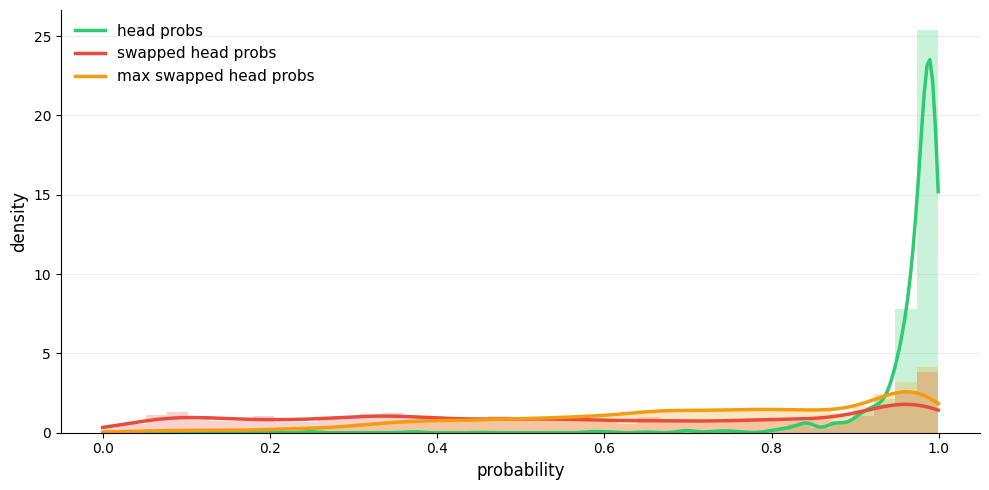

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 5))

sub_df = swap_df[~swap_df.head_prob.isna()]

data = {
    'head probs': (sub_df.head_prob, '#2ecc71'),
    'swapped head probs': (sub_df.swapped_head_prob, '#e74c3c'),
    'max swapped head probs': (sub_df.max_swapped_head_prob, '#f39c12'),
}

# Shared bin edges for all three histograms
all_vals = np.concatenate([
    sub_df.head_prob, 
    sub_df.swapped_head_prob, 
    sub_df.max_swapped_head_prob
])
bins = np.linspace(all_vals.min(), all_vals.max(), 40)

for label, (data_arr, color) in data.items():
    # Histogram (normalized to density)
    ax.hist(data_arr, bins=bins, density=True, alpha=0.25, color=color, edgecolor='none')
    
    # KDE overlay
    kde = gaussian_kde(data_arr, bw_method=0.15)
    x = np.linspace(all_vals.min(), all_vals.max(), 300)
    ax.plot(x, kde(x), color=color, linewidth=2.5, label=label)

ax.set_xlabel('probability', fontsize=12)
ax.set_ylabel('density', fontsize=12)
ax.legend(frameon=False, fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

In [59]:
sub_df.groupby(["original_order", "swap_order"]).mean(["max_swapped_head_prob"])["max_swapped_head_prob"]

original_order  swap_order
osV             oVs           0.515639
                soV           0.962385
sVo             Vos           0.622852
                Vso           0.588047
                oVs           0.930739
                osV           0.653345
                soV           0.785082
Name: max_swapped_head_prob, dtype: float64

In [56]:
from word_order.tree_utils import deserialize_tree, compare_trees

for _, row in sub_df[sub_df.max_swapped_head_prob > 0.99].iterrows():
    if row.sen_len > 13:
        continue
        
    print(row.sen_str)
    print(row.swapped_sen_str)
    print()
    break

orig_tree = deserialize_tree(row.original_tree)
swap_tree = deserialize_tree(row.swapped_tree)

compare_trees(orig_tree, swap_tree)

That money has prevented the militant islamists from achieving their goals.
Has the militant islamists prevented that money from achieving their goals.



In [58]:
row.swap_order

'oVs'

In [111]:
(sub_df.max_swapped_head_prob > 0.7).mean(), (sub_df.max_swapped_head_prob > 0.8).mean(), (sub_df.max_swapped_head_prob > 0.9).mean()

(0.33032128514056225, 0.2459839357429719, 0.12751004016064257)

In [8]:
(sub_df.max_swapped_head_prob > 0.7).mean(), (sub_df.max_swapped_head_prob > 0.8).mean(), (sub_df.max_swapped_head_prob > 0.9).mean()

(0.2947686116700201, 0.20925553319919518, 0.09456740442655935)

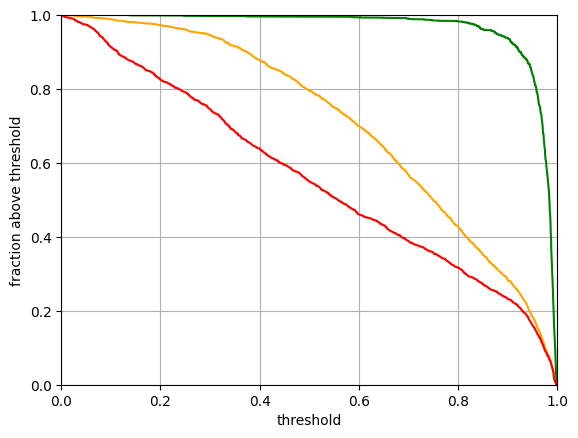

In [45]:
import numpy as np
import matplotlib.pyplot as plt


x = np.sort(sub_df.max_swapped_head_prob.values)
frac_above = 1 - np.arange(1, len(x) + 1) / len(x)
plt.plot(x, frac_above, color='orange')

x = np.sort(sub_df.head_prob.values)
frac_above = 1 - np.arange(1, len(x) + 1) / len(x)
plt.plot(x, frac_above,  color='g')

x = np.sort(sub_df.swapped_head_prob.values)
frac_above = 1 - np.arange(1, len(x) + 1) / len(x)
plt.plot(x, frac_above, color='r')


plt.xlabel("threshold")
plt.ylabel("fraction above threshold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [99]:
for _, row in swap_df[swap_df.max_swapped_head_prob > 0.9].iterrows():
    print(row.sen_str)
    print(row.swapped_sen_str)
    print()
    if "Adolphe" in row.sen_str:
        break

Bernard Reint Siertsema (29) zit op wat een burger een flinke boerderij noemt (de gevel is een beetje statig en de schuur is vooral hoog) zoals er meer en wel grotere zijn in de omgeving van 't Zandt, op de klei in de kop van Groningen.
Bernard Reint Siertsema (29) zit op wat een burger een boerderij flinke noemt (de gevel is een beetje statig en de schuur is vooral hoog) zoals er meer en wel grotere zijn in de omgeving van 't Zandt, op de klei in de kop van Groningen.

Deze verwikkelingen in België maakten deel uit van de ontstaansgeschiedenis van het internationale gloeilampenkartel "Phoebus", dat evenwichtige marktverhoudingen, verdeling van de markten en bestrijding van outsider-concurrenten beoogde, samen met een behoedzaam prijsbeleid.
Deze verwikkelingen in België maakten deel uit van de ontstaansgeschiedenis van het internationale gloeilampenkartel "Phoebus", dat evenwichtige marktverhoudingen, verdeling van de markten en bestrijding van outsider-concurrenten beoogde, samen met

In [100]:
row.attachment_probs

({8: 0.00028112268832152214, 10: 0.99689408870318},
 {2: 0.9056119947112556, 9: 0.007950893922674345, 11: 0.0007036625700854433})

In [101]:
from word_order.tree_utils import deserialize_tree, compare_trees

compare_trees(row.original_tree, row.swapped_tree)

In [88]:
score_swap_df(
    row.to_frame().T,
    joint_classifier
)

Extracting features: 100%|████████████████████████| 1/1 [00:00<00:00, 61.03it/s]


,head_child-feat_acl_VerbForm,amod_under_obl,amod_sibling-deprel_flat,head_sibling-feat_nmod_ExtPos,amod_sibling-feat_conj_Tense,head_child-feat_nmod_ExtPos,head_under_xcomp,head_sibling-feat_nmod:poss_Person,head_sibling-feat_nsubj:pass_PronType,amod_sibling-deprel-L_csubj,...,swapped_child_id,head_was_moved,original_head_id,swapped_head_id,original_tree,swapped_tree,attachment_probs,head_prob,swapped_head_prob,max_swapped_head_prob
134,_missing,0,0,_missing,_missing,_missing,0,_missing,_missing,0,...,10,False,10,9,# archive = WR-P-E-I-enhanced-train.collection...,# archive = WR-P-E-I-enhanced-train.collection...,"({8: 0.0002838108428602735, 10: 0.997528839050...",0.997529,0.188554,0.954451


In [6]:
from word_order.validate_swap_directly import score_heads


scores, item, maps, feats = score_heads(
    orig_tree,
    joint_classifier,
    row.original_child_id,
)

# for col, val in item[0].items():
#     if val.item() and val.item() != '_missing' and val.item() != "False":
#         print(col, val.item())

scores

100%|█████████████████████████████████████████████| 2/2 [00:00<00:00,  3.31it/s]


[(2, 0.7943661971830986, 18), (8, 0.858, 32)]

In [7]:
scores, item, maps, feats = score_heads(
    swap_tree,
    joint_classifier,
    row.swapped_child_id,
)
scores

100%|█████████████████████████████████████████████| 2/2 [00:00<00:00,  3.25it/s]


[(1, 0.29004854368932037, 193), (7, 0.006572769953051643, 18)]

In [41]:
item[1].head_pos

0    NOUN
Name: head_pos, dtype: object

In [66]:
import numpy as np
import pandas as pd
from collections import Counter


d = {}

for col in df.columns:
    try:
        c = np.nansum(df[col])
        if isinstance(c, int):
            d[col] = c
    except TypeError:
        pass
        

d2 = {}

for col in d.keys():
    d2[col] = (df[df[col]].label == "Y").mean()

In [67]:
for col, c in Counter(d).most_common():
    print(col, c, d2[col])

head_sibling-pos-CHs_NOUN 30 0.5
head_sibling-deprel-HCs_punct 30 0.5666666666666667
head_sibling-pos-HCs_PUNCT 30 0.5666666666666667
child_sibling-deprel-CsH_advmod 27 0.2222222222222222
child_sibling-deprel-sHC_nsubj 24 0.375
child_sibling-pos-CsH_ADV 24 0.25
head_sibling-deprel-sHC_nsubj 24 0.5
child_sibling-deprel-HCs_punct 23 0.391304347826087
child_sibling-pos-HCs_PUNCT 23 0.391304347826087
head_sibling-pos-sHC_NOUN 22 0.5
child_sibling-deprel-CHs_punct 20 0.6
child_sibling-pos-CHs_PUNCT 20 0.6
child_sibling-pos-sHC_AUX 20 0.4
head_sibling-deprel-CHs_punct 20 0.5
head_sibling-pos-CHs_PUNCT 20 0.5
child_sibling-pos-sHC_ADV 20 0.35
child_sibling-deprel-sHC_advmod 19 0.3684210526315789
child_sibling-deprel-CHs_cop 18 0.6111111111111112
child_sibling-pos-CHs_AUX 18 0.6111111111111112
child_sibling-deprel-sHC_cop 18 0.4444444444444444
head_sibling-deprel-sCH_punct 18 0.5555555555555556
head_sibling-pos-sCH_PUNCT 18 0.5555555555555556
head_sibling-pos-HsC_NOUN 16 0.5625
head_sibling-de

In [4]:
head_df, child_df = split_node_dfs(combined_df)

all_feats, _, all_deprel, all_pos = get_all_feats(treebank)

classifiers = fit_reattachment_classifiers(
    head_df, child_df, all_feats, all_deprel, all_pos, verbose=True, viz_dir="../word_order/validation_trees"
)

<string>:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


  fitting cc
  cc: head=23462 samples (11731 pos), train_acc=0.993  |  child=23492 samples (11746 pos), train_acc=0.994  |  base_rate=0.0260
  fitting det
  det: head=112522 samples (56261 pos), train_acc=0.996  |  child=112742 samples (56371 pos), train_acc=0.998  |  base_rate=0.1249
  fitting nmod
  nmod: head=49106 samples (24553 pos), train_acc=0.889  |  child=53956 samples (26978 pos), train_acc=0.945  |  base_rate=0.0598
  fitting obl
  obl: head=35092 samples (17546 pos), train_acc=0.753  |  child=48032 samples (24016 pos), train_acc=0.814  |  base_rate=0.0532
  fitting obl:arg
  obl:arg: head=11064 samples (5532 pos), train_acc=0.734  |  child=11066 samples (5533 pos), train_acc=0.858  |  base_rate=0.0123
  fitting nsubj:pass
  nsubj:pass: head=10224 samples (5112 pos), train_acc=0.997  |  child=10224 samples (5112 pos), train_acc=0.991  |  base_rate=0.0113
  fitting obj
  obj: head=29240 samples (14620 pos), train_acc=0.907  |  child=29242 samples (14621 pos), train_acc=0.934 

In [89]:
%load_ext autoreload
%autoreload 2
    
import os
import ast
from tqdm import tqdm_notebook
from glob import glob

sys.path.append("../src")

from multiblimp.languages import get_ud_langs

from word_order.create_pairs import create_pairs
from word_order.prediction_target import *
from word_order.process_treebank import load_treebank


import pandas as pd


random.seed(42)

target = nmod_noun_target

deprel_dir = "_".join(target.child_deprels)
dt_df_dir = f"/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/dt_df/{deprel_dir}"
pair_dir = f"/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/pairs/{deprel_dir}"
word_order_dir = f"/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/treebank_features/{deprel_dir}"

langs = [path.split('/')[-1].split('.')[0] for path in glob(word_order_dir+"/*.csv")]
langs = ["Dutch"]


for lang in tqdm_notebook(sorted(langs), total=len(langs)):
    dt_df = pd.read_csv(
        os.path.join(dt_df_dir, f"{lang}.csv"),
        converters={
            "sen": ast.literal_eval, 
            "swap_order_candidates": ast.literal_eval
        },
    )
    
    balance_features = ["sen_len", "head_form"]
    balance_features += [f"{deprel}_form" for deprel in target.child_deprels]
    
    treebank = load_treebank(lang, resource_dir, max_treebank_len=MAX_TREEBANK_LEN)
    swap_df = create_pairs(
        dt_df,
        treebank, 
        target,
        balance_features=balance_features,
        save_to=os.path.join(pair_dir, f"{lang}.csv"),
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_27624/3629115338.py:34: TqdmDeprecationWarning:

This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`



  0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_27624/3629115338.py:35: DtypeWarning:

Columns (604,607,610,612,615,620,623,625,630,639,651,653,655,656,660,672,677,682,684,685,687,690,695,697,698,703,704,707,714,719,722,724,734) have mixed types. Specify dtype option on import or set low_memory=False.



1000


/home/jaap/Documents/multiblimp/notebooks/../src/word_order/create_pairs.py:297: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [92]:
row = swap_df.iloc[0]

print(row.sen_str)
print(row.swapped_sen_str)
row.sent_id

De rij met schietbomen vormt dan ook het eigenlijke focuspunt van het feestterrein.
De rij met schietbomen vormt dan ook het eigenlijke van het feestterrein focuspunt.


'WR-P-E-I-0000039352.p.3.s.217'

In [75]:
from word_order.huggingface import upload


pair_dir = f"/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/pairs"
upload(pair_dir, "jumelet/multiblimp-word-order")

Loading pairs from /media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/pairs ...


Uploading subsets:   0%|                                | 0/119 [00:00<?, ?it/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        : 100%|##########| 23.6kB / 23.6kB            

...

New Data Upload                         : |          |  0.00B /  0.00B            

                                        : 100%|##########|  215kB /  215kB            

README.md: 0.00B [00:00, ?B/s]

Uploading subsets: 100%|██████████████████████| 119/119 [09:11<00:00,  4.64s/it]

Done. Dataset available at https://huggingface.co/datasets/jumelet/multiblimp-word-order


In [69]:
import lm_eval

lm_eval.__version__

'0.4.11'

In [71]:
from datasets import load_dataset

ds = load_dataset("jumelet/multiblimp-word-order", "Dutch")

Dutch/advmod-00000-of-00001.parquet:   0%|          | 0.00/145k [00:00<?, ?B/s]

Dutch/amod-00000-of-00001.parquet:   0%|          | 0.00/253k [00:00<?, ?B/s]

Dutch/nsubj_obj-00000-of-00001.parquet:   0%|          | 0.00/227k [00:00<?, ?B/s]

Dutch/obl-00000-of-00001.parquet:   0%|          | 0.00/89.3k [00:00<?, ?B/s]

Generating advmod split:   0%|          | 0/667 [00:00<?, ? examples/s]

Generating amod split:   0%|          | 0/999 [00:00<?, ? examples/s]

Generating nsubj_obj split:   0%|          | 0/3870 [00:00<?, ? examples/s]

Generating obl split:   0%|          | 0/488 [00:00<?, ? examples/s]

In [64]:
Counter(swap_df[swap_df.keep].amod_form).most_common(10)

[('Zorggerichte', 1),
 ('avondlijke', 1),
 ('West-Duitse', 1),
 ('Oosteuropese', 1),
 ('onbekend', 1),
 ('ouderwetse', 1),
 ('Zuidafrikaanse', 1),
 ('Bloemendaalse', 1),
 ('fiscaal', 1),
 ('aanstaande', 1)]

In [30]:
row = swap_df.iloc[0]

print(row["Na_sen_str"])
print(row["aN_sen_str"])

Donderdag won Lodewijk Meeter met Siete Meeter op de plaats tweede;
Donderdag won Lodewijk Meeter met Siete Meeter op de tweede plaats;


In [17]:
row = swap_df.iloc[0]

print(row["Nn_sen_str"])
print(row["nN_sen_str"])

Hij stuurde zijn minister van de Vrede naar een bespreking met de Amerikaanse president George W. Bush om bezwaren tegen die oorlog over te brengen, zoals hij dit ook al gedaan had bij de Eerste Golfoorlog in 1991.
Hij stuurde zijn minister van de Vrede naar een bespreking met de Amerikaanse president George W. Bush om tegen die oorlog bezwaren over te brengen, zoals hij dit ook al gedaan had bij de Eerste Golfoorlog in 1991.


In [27]:
from word_order.viz_tree import get_sample_ids

prep = model.named_steps["preprocessor"]
clf = model.named_steps["clf"]

predictor_value = 'Nn'

sample_ids = get_sample_ids(prep, clf, dt_df, predictor_var, max_rows=15)

# Pick the predictor_value where you saw the bug
# Check node 2
node_2_ids = sample_ids[predictor_value][2]  # adjust predictor_value accordingly

X_check = prep.transform(dt_df.loc[node_2_ids])
paths = clf.decision_path(X_check)
visits_node_2 = paths[:, 2].toarray().flatten().astype(bool)

print("All visit node 2?", visits_node_2.all())
print("Count that don't:", (~visits_node_2).sum())


All visit node 2? True
Count that don't: 0


In [36]:
for idx, ids in sample_ids['nN'].items():
    for jdx in ids:
        print(idx, dt_df.loc[jdx].leaf_id)

0 3
0 3
0 3
0 3
0 2
0 2
0 4
0 4
0 2
0 2
0 2
0 2
0 2
0 3
0 3
1 3
1 3
1 3
1 3
1 3
1 3
1 2
1 3
1 3
1 2
1 3
1 3
1 2
1 2
1 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
2 2
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
4 4
4 4
4 4
4 4
4 4
4 4
4 4
4 4
4 4
4 4
4 4
4 4
4 4
4 4
4 4


In [44]:
for idx, row in dt_df.iterrows():
    # if row.sen == ['Dit', 'soort', 'verhalen', 'berusten', 'echter', 'zelden', 'op', 'bewijzen', '.']:
    if "duikbootmotor" in row.sen:
        print(row.sen, row.leaf_id, idx, row['nmod_child-feat_det_Definite'], full_df.loc[idx].nmod_form, full_df.loc[idx].head_form)
        # break


['Het', 'geval', 'van', 'dertig', 'meter', 'lengte', 'en', '300', 'ton', 'gewicht', '(', 'door', 'een', 'pantsering', 'van', '76', 'mm', 'rondom', ')', 'moest', 'voorzien', 'worden', 'van', 'drie', 'gevechtstorens', ',', 'ieder', 'bewapend', 'met', 'twee', '102', 'mm', 'kanonnen', 'en', 'voortgestuwd', 'worden', 'door', 'een', '800', 'pk', 'duikbootmotor', '.'] 4 5133 Ind pantsering ton
['Het', 'geval', 'van', 'dertig', 'meter', 'lengte', 'en', '300', 'ton', 'gewicht', '(', 'door', 'een', 'pantsering', 'van', '76', 'mm', 'rondom', ')', 'moest', 'voorzien', 'worden', 'van', 'drie', 'gevechtstorens', ',', 'ieder', 'bewapend', 'met', 'twee', '102', 'mm', 'kanonnen', 'en', 'voortgestuwd', 'worden', 'door', 'een', '800', 'pk', 'duikbootmotor', '.'] 4 5131 _missing meter geval
['Het', 'geval', 'van', 'dertig', 'meter', 'lengte', 'en', '300', 'ton', 'gewicht', '(', 'door', 'een', 'pantsering', 'van', '76', 'mm', 'rondom', ')', 'moest', 'voorzien', 'worden', 'van', 'drie', 'gevechtstorens', ',

In [34]:
dt_df.loc[idx].leaf_id

4

In [114]:
from multiblimp.unimorph import UnimorphInflector


langcode = "fra"
inflection_map = (["Number[subj]", "Number"], None)
inflector = UnimorphInflector(langcode, inflection_map, resource_dir=resource_dir, verbose=True)

In [128]:
form = "mis"
morph_feats = {'Voice': 'Act', 'VerbForm': 'Part', 'Gender': 'Masc'}
inflector.get_form_features(form, features=morph_feats, only_try_ud_if_no_um=True, prefer_tight_match=True)

UM Features: {'VerbForm': 'V.PTCP', 'Gender': 'MASC'}
Tight matching #added features: {'VerbForm': 'V.PTCP', 'Gender': 'MASC'} [10.  8. 10. 10.]
Tight matching yielded:
         lemma form               ufeat Aspect Finiteness     Gender Mood  \
235652   metre  mis  V;IND;PST;1;SG;PFV    PFV        NaN  UNDEFINED  IND   
235653   metre  mis          V.PTCP;PST    NaN        NaN  UNDEFINED  IND   
483779  mettre  mis  V;IND;PST;PFV;1;SG    PFV        NaN  UNDEFINED  IND   
483780  mettre  mis  V;IND;PST;PFV;2;SG    PFV        NaN  UNDEFINED  IND   

           Number upos VerbForm     Person Polarity Tense  
235652         SG    V      NaN          1      NaN   PST  
235653  UNDEFINED    V   V.PTCP  UNDEFINED      NaN   PST  
483779         SG    V      NaN          1      NaN   PST  
483780         SG    V      NaN          2      NaN   PST  
to
        lemma form       ufeat Aspect Finiteness     Gender Mood     Number  \
235653  metre  mis  V.PTCP;PST    NaN        NaN  UNDEFINED  IN

{'UNDEFINED'}

In [109]:
df = inflector.unimorph_df
df[df.form == "mis"]

,lemma,form,ufeat,Aspect,Finiteness,Gender,Mood,Number,upos,VerbForm,Person,Polarity,Tense
235652,metre,mis,V;IND;PST;1;SG;PFV,PFV,NaN,UNDEFINED,IND,SG,V,NaN,1,NaN,PST
235653,metre,mis,V.PTCP;PST,NaN,NaN,UNDEFINED,IND,UNDEFINED,V,V.PTCP,UNDEFINED,NaN,PST
483779,mettre,mis,V;IND;PST;PFV;1;SG,PFV,NaN,UNDEFINED,IND,SG,V,NaN,1,NaN,PST
483780,mettre,mis,V;IND;PST;PFV;2;SG,PFV,NaN,UNDEFINED,IND,SG,V,NaN,2,NaN,PST


In [6]:
from word_order.viz_deprel import generate_html_deprel_index


deprel = "_".join(target.child_deprels)
# deprel = "amod"

generate_html_deprel_index(
    f"/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/dt_df/{deprel}", 
    f"word_order/decision_trees/html/{deprel}/",
    language_data=lang2data,
)

100%|█████████████████████████████████████████| 157/157 [01:15<00:00,  2.09it/s]


In [7]:
from word_order.viz_overview import generate_html_overview_index


generate_html_overview_index('word_order/decision_trees/html/')

In [17]:
from tqdm import tqdm


rows = []

for _, row in tqdm(full_df.iterrows()):
    for order in row.swap_order_candidates:
        rows.append((row.language, row.sen_str, row[f"{order}_sen_str"], row.core_args, order))

swap_df = pd.DataFrame(rows, columns=["language", "sen", "swap_sen", "sen_order", "swap_order"])
swap_df.to_csv("word_order/pairs/all_pairs.csv", index=False)

In [20]:
import pickle

with open("lang2data.pickle", "wb") as f:
    pickle.dump(lang2data, f)

full_df.to_csv("full_df.csv", index=False)

In [63]:
threshold = 0.1
swap_so = str.maketrans({"s": "o", "o": "s"})

correct_num_swaps = []
all_swap_order_candidates = []

all_orders = {"svo", "ovs", "osv", "sov", "vos", "vso"}

for _, row in dt_df.iterrows():
    core_arg = row.core_args
    swap_orders = all_orders - {core_arg, core_arg.translate(swap_so)}

    swap_order_candidates = [
        arg_order
        for arg_order in swap_orders
        if row[f"{arg_order}_entropy"] < threshold
    ]
    
    num_swaps = len(swap_order_candidates)
    
    correct_num_swaps.append(num_swaps)
    all_swap_order_candidates.append(swap_order_candidates)

dt_df["num_swaps"] = correct_num_swaps
dt_df["swap_order_candidates"] = all_swap_order_candidates

In [75]:
(swap_df["num_swaps"] > 0).mean()

0.0

In [49]:
row[[
    f"{arg_order}_entropy"
    for arg_order in swap_orders
]] < 0.04

vso_entropy    False
osv_entropy     True
sov_entropy     True
vos_entropy     True
Name: 996, dtype: bool

In [22]:
generate_html_index('word_order/decision_trees/html/')

In [24]:
"core_args" in raw_df.columns

False

In [37]:
"this Is a test".capitalize()

'This is a test'